In [2]:
import pandas as pd
import numpy as np
import torch
import json
import os

os.makedirs('../data/processed', exist_ok=True)

In [3]:
reviews_df = pd.read_parquet('../data/clean_reviews.parquet')
meta_df = pd.read_parquet('../data/clean_meta.parquet')

In [4]:
# Inductive Split: 10% users hidden for 'Device' inference
all_users = reviews_df['reviewerID'].unique()
np.random.seed(42)
shuffled_users = np.random.permutation(all_users)
split_idx = int(len(shuffled_users) * 0.9)

seen_users = shuffled_users[:split_idx]
hidden_users = shuffled_users[split_idx:]

seen_interactions = reviews_df[reviews_df['reviewerID'].isin(seen_users)].copy()
hidden_interactions = reviews_df[reviews_df['reviewerID'].isin(hidden_users)].copy()

print(f"Total Users: {len(all_users)}")
print(f"Seen Users (Cloud Training): {len(seen_users)}")
print(f"Hidden Users (Device): {len(hidden_users)}")

Total Users: 1825
Seen Users (Cloud Training): 1642
Hidden Users (Device): 183


In [5]:
all_users

<ArrowStringArray>
['A38NELQT98S4H8', 'A3QJU4FEN8PQSZ',  'ACJT8MUC0LRF0',  'AYUF7YETYOLNX',
 'A31ICLWQ9CSHRS', 'A2BVNVJOFXGZUB', 'A2JMJVNTBL7K7E', 'A14JBDSWKPKTZA',
 'A2WCFDOCS73PNB', 'A14638TGYH7GD9',
 ...
 'A1SE0LK82QXOGZ',  'AOOWG6KYD32UJ', 'A10SE0U42ABS9S',  'AH5WJ8JEGYTDR',
  'AJUQPCJGQUZV8', 'A1DSGNHMAGNLTZ',  'A3LP3J8DDX4NX',  'AGBZ9NGMQHN1I',
 'A1H378KKY8V01U',  'A34AN3NF8P7PJ']
Length: 1825, dtype: str

In [6]:
# Node Identifier Mapping -> Integer IDs (0 to N-1)
user_mapping = {user_id: idx for idx, user_id in enumerate(seen_users)}
all_items = meta_df['asin'].unique()
item_mapping = {item_id: idx for idx, item_id in enumerate(all_items)}

with open('../data/processed/user_mapping.json', 'w') as f:
    json.dump(user_mapping, f)
with open('../data/processed/item_mapping.json', 'w') as f:
    json.dump(item_mapping, f)

In [7]:
# Bipartite Edge Mapping
mapped_users = seen_interactions['reviewerID'].map(user_mapping)
mapped_items = seen_interactions['asin'].map(item_mapping)

valid_edges = mapped_users.notna() & mapped_items.notna()
u_nodes = mapped_users[valid_edges].astype(int).values
i_nodes = mapped_items[valid_edges].astype(int).values

user_item_edge_index = torch.tensor([u_nodes, i_nodes], dtype=torch.long)
print(f"User-Item Edge Index Shape: {user_item_edge_index.shape}")

User-Item Edge Index Shape: torch.Size([2, 10751])


/tmp/ipykernel_36494/3778904298.py:9: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  user_item_edge_index = torch.tensor([u_nodes, i_nodes], dtype=torch.long)


In [8]:
# Item-Item Edge Mapping ('also_buy')
source_items = []
target_items = []

for idx, row in meta_df.dropna(subset=['also_buy']).iterrows():
    src_idx = item_mapping.get(row['asin'])
    if src_idx is not None:
        # Also_buy might be a NumPy array, list, or string depending on parsing
        also_buy = row['also_buy']
        if isinstance(also_buy, str):
            # try converting to list if it was parsed as string
            try:
                import ast
                also_buy = ast.literal_eval(also_buy)
            except:
                also_buy = []
        if isinstance(also_buy, (list, np.ndarray)):
            for tgt_item in also_buy:
                tgt_idx = item_mapping.get(tgt_item)
                if tgt_idx is not None:
                    source_items.append(src_idx)
                    target_items.append(tgt_idx)

item_item_edge_index = torch.tensor([source_items, target_items], dtype=torch.long)
print(f"Item-Item Edge Index Shape: {item_item_edge_index.shape}")

Item-Item Edge Index Shape: torch.Size([2, 7253])


In [9]:
user_item_edge_index.shape

torch.Size([2, 10751])

In [10]:
user_item_edge_index

tensor([[ 1082,  1588,   938,  ...,   166,  1432,   968],
        [   89,    89,    89,  ..., 21626, 21625, 21625]])

In [11]:
item_item_edge_index.shape

torch.Size([2, 7253])

In [12]:
item_item_edge_index

tensor([[  103,   103,   110,  ..., 21628, 21638, 21638],
        [ 2822,  7929,  1017,  ..., 19087, 21530, 17249]])

In [13]:
len(item_mapping)

21639

In [14]:
item_mapping

{'0030672120': 0,
 '0071480935': 1,
 '007329506X': 2,
 '0073513458': 3,
 '0073525758': 4,
 '0077340701': 5,
 '0077369823': 6,
 '0077410297': 7,
 '007739688X': 8,
 '0077410319': 9,
 '007741232X': 10,
 '007742817X': 11,
 '0077411927': 12,
 '0077421027': 13,
 '0077451058': 14,
 '0077438760': 15,
 '0077451287': 16,
 '007744017X': 17,
 '0077457501': 18,
 '0077500741': 19,
 '0077495020': 20,
 '0077492951': 21,
 '0077510585': 22,
 '0077479777': 23,
 '0077494997': 24,
 '0077514769': 25,
 '0077515587': 26,
 '0077510313': 27,
 '0077538641': 28,
 '0077518101': 29,
 '0077508483': 30,
 '0077587111': 31,
 '0077595696': 32,
 '0077601408': 33,
 '007760072X': 34,
 '0077613252': 35,
 '0077602471': 36,
 '0077631048': 37,
 '0077648331': 38,
 '0077677315': 39,
 '007773162X': 40,
 '0077627008': 41,
 '0077773284': 42,
 '0077767004': 43,
 '0077772229': 44,
 '0077796934': 45,
 '0077806700': 46,
 '0077775473': 47,
 '0077772466': 48,
 '0077734343': 49,
 '0077800923': 50,
 '0078094100': 51,
 '0078137403': 52,
 '0

In [15]:
user_mapping

{'A5Q1FK0FWU7DH': 0,
 'A2ZFQ9RT9Y9NQN': 1,
 'A13LA6WF3JLEZR': 2,
 'A22TZUXUKA11SQ': 3,
 'A2IS5YJF9DDOHE': 4,
 'A27HD5O3TRWITN': 5,
 'A3VI2VETB90ZG5': 6,
 'A1UQOCC5QU9GCU': 7,
 'A3L1MEXXDI4Q77': 8,
 'A1IO93OKI5A23F': 9,
 'A3E4OLI1U8WA5W': 10,
 'A1G6M86XS35YS3': 11,
 'AH91ZJ8W8NCLR': 12,
 'A1Y3PKMAQEVHK7': 13,
 'A1QLHQ4PWOZRX5': 14,
 'A1THNW9Y672UWG': 15,
 'A2SI5MM8V6W133': 16,
 'A1B6SIX2I161O9': 17,
 'A397CWU6DM3O5G': 18,
 'AUVBT6VI1P66': 19,
 'A3L9WM6LGIM0NF': 20,
 'A1MLX3KJD59GZZ': 21,
 'AFYPYQAFA31JU': 22,
 'AFBXQDFJF33VS': 23,
 'A2NWOSRE9LD49T': 24,
 'A3D44572MFVIMI': 25,
 'A390UFRRO2BLZS': 26,
 'A3RA7ZWPU69LZ7': 27,
 'A3V6Z4RCDGRC44': 28,
 'A1GNYKVAT4ZHT1': 29,
 'AZQGJ5CEAJGXB': 30,
 'APU7YT7IBAR1H': 31,
 'ANGGNFE8DXGYC': 32,
 'AYC0OSX1B9EC5': 33,
 'A1PL7QILVQV3IF': 34,
 'A38LDNT0ACG2Q6': 35,
 'A167KI3P7XN1AM': 36,
 'A20S4G1EXF2OM7': 37,
 'A1TKPBCD3A1814': 38,
 'AX329NHW6B7BA': 39,
 'A7G2OFKFUP8X9': 40,
 'A3HJHV83O2U8BL': 41,
 'A361NBC6JJAOWC': 42,
 'A2TXR85WQLE32N': 43,
 'A2PXBHHY

In [16]:
len(user_mapping)

1642

## Graph Visualization

To better understand the network structure, we will visualize a small sampled subgraph of the graphs. Since the full graph has tens of thousands of nodes and edges, rendering it entirely would result in a dense and unreadable 'hairball'. We sample a few dozen edges simply to observe the structural patterns.

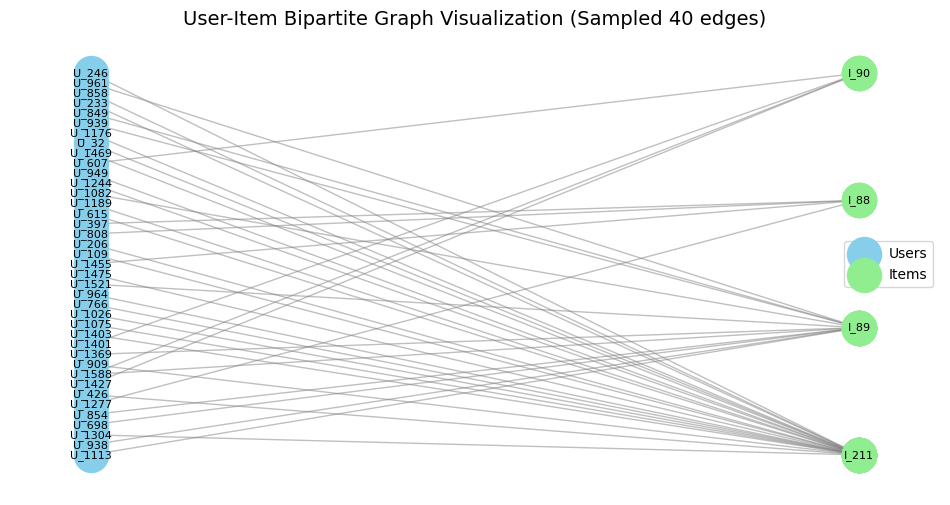

In [20]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_bipartite_subgraph(edge_index, num_edges=50):
    # Lấy mẫu một phần nhỏ đồ thị để tránh bị rối
    edges = edge_index[:, :num_edges].numpy()
    
    B = nx.Graph()
    # Tạo 2 tập hợp đỉnh: User (U_...) và Item (I_...)
    users = [f"U_{u}" for u in edges[0]]
    items = [f"I_{i}" for i in edges[1]]
    
    B.add_nodes_from(users, bipartite=0)
    B.add_nodes_from(items, bipartite=1)
    
    # Thêm cạnh (lượt mua/đánh giá)
    B.add_edges_from(zip(users, items))
    
    plt.figure(figsize=(12, 6))
    # Tách vị trí 2 bên: Users ở bên trái, Items ở bên phải (hoặc trên/dưới)
    top_nodes = {n for n, d in B.nodes(data=True) if d['bipartite'] == 0}
    pos = nx.bipartite_layout(B, top_nodes)
    
    # Vẽ Users
    nx.draw_networkx_nodes(B, pos, nodelist=users, node_color='skyblue', node_size=600, label='Users')
    # Vẽ Items
    nx.draw_networkx_nodes(B, pos, nodelist=items, node_color='lightgreen', node_size=600, label='Items')
    
    nx.draw_networkx_edges(B, pos, alpha=0.5, edge_color='gray')
    nx.draw_networkx_labels(B, pos, font_size=8)
    
    plt.legend()
    plt.title(f"User-Item Bipartite Graph Visualization (Sampled {num_edges} edges)", fontsize=14)
    plt.axis("off")
    plt.show()

# Gọi hàm vẽ đồ thị User-Item với 40 cạnh
plot_bipartite_subgraph(user_item_edge_index, num_edges=40)

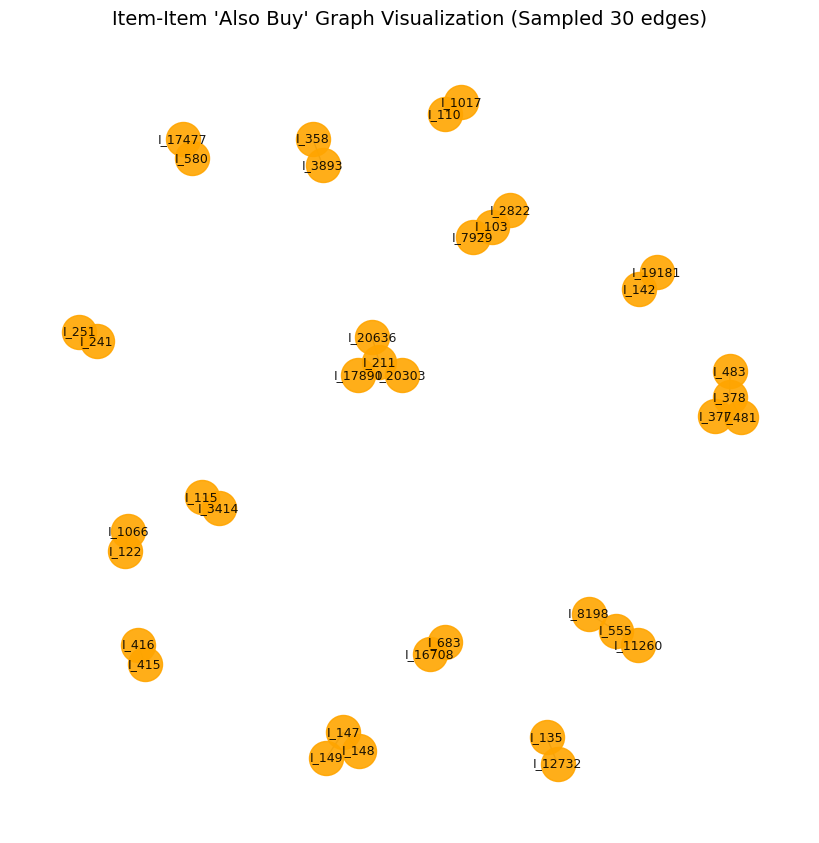

In [21]:
def plot_item_item_subgraph(edge_index, num_edges=50):
    edges = edge_index[:, :num_edges].numpy()
    
    G = nx.Graph()
    sources = [f"I_{s}" for s in edges[0]]
    targets = [f"I_{t}" for t in edges[1]]
    
    G.add_edges_from(zip(sources, targets))
    
    plt.figure(figsize=(8, 8))
    pos = nx.spring_layout(G, seed=42) # Xếp các đỉnh ngẫu nhiên nhưng đảm bảo lực kéo giống lò xo
    
    nx.draw(G, pos, with_labels=True, node_color='orange', node_size=600, 
            edge_color='gray', font_size=9, alpha=0.9)
    
    plt.title(f"Item-Item 'Also Buy' Graph Visualization (Sampled {num_edges} edges)", fontsize=14)
    plt.axis("off")
    plt.show()

# Gọi hàm vẽ đồ thị Item-Item với 30 cạnh
plot_item_item_subgraph(item_item_edge_index, num_edges=30)

In [19]:
torch.save(user_item_edge_index, '../data/processed/user_item_edge_index.pt')
torch.save(item_item_edge_index, '../data/processed/item_item_edge_index.pt')
hidden_interactions.to_parquet('../data/processed/hidden_interactions_test.parquet', index=False)
print("Artifacts successfully saved to data/processed/")

Artifacts successfully saved to data/processed/
